# Preparación de datos demográficos de OWID (2000–2022)

**Objetivo:** descargar cuatro conjuntos de datos demográficos y dos indicadores económicos/sanitarios, revisar sus columnas, preparar cada uno por separado y unirlos por `entity` y `year`. El resultado servirá para una práctica posterior de aprendizaje automático.

Ejecuta las celdas en orden. Requiere `pandas` y `matplotlib`, además de acceso a internet. Fuente: [Our World in Data](https://ourworldindata.org/).

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

OPCIONES_OWID = {"User-Agent": "Our World In Data data fetch/1.0"}
BASE = "https://ourworldindata.org/grapher/"
SUFIJO = ".csv?v=1&csvType=full&useColumnShortNames=true"


## 1. Descargar las seis fuentes

Las cuatro primeras fuentes aportan los indicadores demográficos. `df` aporta gasto corriente en salud como porcentaje del PIB (`percentage_health`) y `df2` aporta PIB per cápita (`gdp`).

In [33]:
url_population = BASE + "population-with-un-projections" + SUFIJO
url_births = BASE + "number-of-births-per-year" + SUFIJO
url_deaths = BASE + "number-of-deaths-per-year" + SUFIJO
url_child_deaths = BASE + "number-of-child-deaths-unwpp" + SUFIJO
url_health = BASE + "total-healthcare-expenditure-gdp" + SUFIJO
url_gdp = BASE + "gdp-per-capita-worldbank" + SUFIJO

df = pd.read_csv(url_health, storage_options=OPCIONES_OWID)
df2 = pd.read_csv(url_gdp, storage_options=OPCIONES_OWID)
population = pd.read_csv(url_population, storage_options=OPCIONES_OWID)
births = pd.read_csv(url_births, storage_options=OPCIONES_OWID)
deaths = pd.read_csv(url_deaths, storage_options=OPCIONES_OWID)
child_deaths = pd.read_csv(url_child_deaths, storage_options=OPCIONES_OWID)

print("Filas y columnas:")
print("population:", population.shape)
print("births:", births.shape)
print("deaths:", deaths.shape)
print("child_deaths:", child_deaths.shape)
print("percentage_health:", df.shape)
print("gdp per capita:", df2.shape)

Filas y columnas:
population: (39562, 5)
births: (39109, 5)
deaths: (38656, 5)
child_deaths: (18942, 4)
percentage_health: (4756, 4)
gdp per capita: (7445, 5)


## 2. Explorar las columnas

OWID puede modificar los nombres de los indicadores. Revisamos las columnas reales de las seis fuentes antes de seleccionarlas.

In [34]:
for nombre, tabla in [("population", population),
                      ("births", births),
                      ("deaths", deaths),
                      ("child_deaths", child_deaths),
                      ("percentage_health", df),
                      ("gdp", df2)]:
    print(f"\n{nombre}: {tabla.columns.tolist()}")
    display(tabla.head(3))


population: ['entity', 'code', 'year', 'population__sex_all__age_all__variant_estimates', 'population__sex_all__age_all__variant_medium__projected']


,entity,code,year,population__sex_all__age_all__variant_estimates,population__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,7776180.0,NaN
1,Afghanistan,AFG,1951,7879343.0,NaN
2,Afghanistan,AFG,1952,7987784.0,NaN



births: ['entity', 'code', 'year', 'births__sex_all__age_all__variant_estimates', 'births__sex_all__age_all__variant_medium__projected']


,entity,code,year,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,383985.0,NaN
1,Afghanistan,AFG,1951,391002.0,NaN
2,Afghanistan,AFG,1952,397663.0,NaN



deaths: ['entity', 'code', 'year', 'deaths__sex_all__age_all__variant_estimates', 'deaths__sex_all__age_all__variant_medium__projected']


...

,entity,code,year,deaths__sex_all__age_0_4__variant_estimates
0,Afghanistan,AFG,1950,160791
1,Afghanistan,AFG,1951,158566
2,Afghanistan,AFG,1952,157832



percentage_health: ['entity', 'code', 'year', 'current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct']


,entity,code,year,current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct
0,Afghanistan,AFG,2002,9.443391
1,Afghanistan,AFG,2003,8.941258
2,Afghanistan,AFG,2004,9.808474



gdp: ['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region']


,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia


## 3. Preparar población

Elegimos la columna de **estimaciones históricas** para ambos sexos y todas las edades; excluimos las proyecciones. Después conservamos los años de interés.

In [15]:
columnas_population = [
    columna for columna in population.columns
        if "population" in columna and "estimates" in columna]

print("Columnas candidatas:", columnas_population)

assert len(columnas_population) == 1, "Revisar manualmente el indicador de población mostrado arriba"


col_population = columnas_population[0]

population_limpio = population[["entity", "year", col_population]].copy()

population_limpio = population_limpio.rename(columns={col_population: "population"})

population_limpio = population_limpio[population_limpio["year"].between(2000, 2022)].copy()

print(population_limpio.shape)
display(population_limpio.head())

Columnas candidatas: ['population__sex_all__age_all__variant_estimates']
(6026, 3)


,entity,year,population
50,Afghanistan,2000,20130334.0
51,Afghanistan,2001,20284303.0
52,Afghanistan,2002,21378123.0
53,Afghanistan,2003,22733053.0
54,Afghanistan,2004,23560656.0


## 4. Preparar nacimientos

Seleccionamos el número anual de nacimientos históricos. Revisamos qué entidades comparte con las otras tablas.

In [16]:
columnas_births = [c for c in births.columns
                  if "births" in c and "estimates" in c]


print("Columnas candidatas:", columnas_births)
assert len(columnas_births) == 1, "Revisar manualmente el indicador de nacimientos mostrado arriba"
col_births = columnas_births[0]

births_limpio = births[["entity", "year", col_births]].copy()
births_limpio = births_limpio.rename(columns={col_births: "births"})
births_limpio = births_limpio[births_limpio["year"].between(2000, 2022)].copy()
print(births_limpio.shape)
display(births_limpio.head())

Columnas candidatas: ['births__sex_all__age_all__variant_estimates']
(5957, 3)


,entity,year,births
50,Afghanistan,2000,1036525.0
51,Afghanistan,2001,1006562.0
52,Afghanistan,2002,1015202.0
53,Afghanistan,2003,1069727.0
54,Afghanistan,2004,1095372.0


## 5. Preparar defunciones totales

In [17]:
columnas_deaths = [c for c in deaths.columns
                   if "deaths" in c and "estimates" in c]

print("Columnas candidatas:", columnas_deaths)
assert len(columnas_deaths) == 1, "Revisar manualmente el indicador de defunciones mostrado arriba"

col_deaths = columnas_deaths[0]

deaths_limpio = deaths[["entity", "year", col_deaths]].copy()
deaths_limpio = deaths_limpio.rename(columns={col_deaths: "deaths"})
deaths_limpio = deaths_limpio[deaths_limpio["year"].between(2000, 2022)].copy()

print(deaths_limpio.shape)
display(deaths_limpio.head())

Columnas candidatas: ['deaths__sex_all__age_all__variant_estimates']
(5888, 3)


,entity,year,deaths
50,Afghanistan,2000,253804.0
51,Afghanistan,2001,242473.0
52,Afghanistan,2002,239161.0
53,Afghanistan,2003,243573.0
54,Afghanistan,2004,244435.0


## 6. Preparar defunciones de menores de cinco años

Este indicador corresponde a niños de 0 a 4 años; no debe confundirse con mortalidad de menores de un año.

In [18]:
columnas_child = [c for c in child_deaths.columns
                  if c not in ["entity", "code", "year"]]

print("Columnas candidatas:", columnas_child)

assert len(columnas_child) == 1, "Revisar manualmente el indicador de menores de cinco años mostrado arriba"

col_child = columnas_child[0]

child_deaths_limpio = child_deaths[["entity", "year", col_child]].copy()
child_deaths_limpio = child_deaths_limpio.rename(columns={col_child: "child_deaths_under_5"})

child_deaths_limpio = child_deaths_limpio[child_deaths_limpio["year"].between(2000, 2022)].copy()

print(child_deaths_limpio.shape)
display(child_deaths_limpio.head())

Columnas candidatas: ['deaths__sex_all__age_0_4__variant_estimates']
(5887, 3)


,entity,year,child_deaths_under_5
50,Afghanistan,2000,133112
51,Afghanistan,2001,125627
52,Afghanistan,2002,123215
53,Afghanistan,2003,123894
54,Afghanistan,2004,122315


## 7. Preparar gasto en salud y PIB per cápita

Seleccionamos el indicador de cada DataFrame, lo renombramos como `percentage_health` y `gdp`, y filtramos a 2000–2022. El PIB de OWID es per cápita (dólares internacionales constantes de 2017, ajustados por paridad de poder adquisitivo); el indicador de salud es porcentaje del PIB.

In [35]:
columnas_health = [c for c in df.columns if c not in ["entity", "code", "year"]]
assert len(columnas_health) == 1, "Revisar la columna de gasto en salud mostrada arriba"
col_health = columnas_health[0]

health_limpio = df[["entity", "year", col_health]].copy()
health_limpio = health_limpio.rename(columns={col_health: "percentage_health"})
health_limpio = health_limpio[health_limpio["year"].between(2000, 2022)].copy()

columnas_gdp = [c for c in df2.columns
                if c not in ["entity", "code", "year", "owid_region"]]
assert len(columnas_gdp) == 1, "Revisar la columna de PIB mostrada arriba"
col_gdp = columnas_gdp[0]

gdp_limpio = df2[["entity", "year", col_gdp]].copy()
gdp_limpio = gdp_limpio.rename(columns={col_gdp: "gdp"})
gdp_limpio = gdp_limpio[gdp_limpio["year"].between(2000, 2022)].copy()

for nombre, tabla in [("percentage_health", health_limpio), ("gdp", gdp_limpio)]:
    duplicados = tabla.duplicated(["entity", "year"]).sum()
    print(nombre, "| filas:", len(tabla), "| llaves duplicadas:", duplicados)
    assert duplicados == 0, f"Llaves duplicadas en {nombre}"

display(health_limpio.head())
display(gdp_limpio.head())

percentage_health | filas: 4555 | llaves duplicadas: 0
gdp | filas: 4823 | llaves duplicadas: 0


,entity,year,percentage_health
0,Afghanistan,2002,9.443391
1,Afghanistan,2003,8.941258
2,Afghanistan,2004,9.808474
3,Afghanistan,2005,9.948289
4,Afghanistan,2006,10.622766


,entity,year,gdp
0,Afghanistan,2000,1617.8264
1,Afghanistan,2001,1454.1108
2,Afghanistan,2002,1774.3087
3,Afghanistan,2003,1815.9282
4,Afghanistan,2004,1776.9182


## 8. Revisar llaves y cobertura

Cada combinación `entity`–`year` debe aparecer una sola vez en cada tabla. `code` no se utiliza como llave porque puede faltar en agregados regionales.

In [36]:
tablas = [("population", population_limpio), ("births", births_limpio),
          ("deaths", deaths_limpio), ("child_deaths", child_deaths_limpio),
          ("percentage_health", health_limpio), ("gdp", gdp_limpio)]

for nombre, tabla in tablas:
    duplicados = tabla.duplicated(["entity", "year"]).sum()
    print(nombre, "| entidades:", tabla["entity"].nunique(),
          "| años:", tabla["year"].min(), "a", tabla["year"].max(),
          "| llaves duplicadas:", duplicados)
    assert duplicados == 0, f"Llaves duplicadas en {nombre}"

entidades_comunes = set(population_limpio["entity"]) & set(births_limpio["entity"]) \
                  & set(deaths_limpio["entity"]) & set(child_deaths_limpio["entity"]) \
                  & set(health_limpio["entity"]) & set(gdp_limpio["entity"])

print("Entidades presentes en las seis fuentes:", len(entidades_comunes))
print(sorted(entidades_comunes)[:30])

population | entidades: 262 | años: 2000 a 2022 | llaves duplicadas: 0
births | entidades: 259 | años: 2000 a 2022 | llaves duplicadas: 0
deaths | entidades: 256 | años: 2000 a 2022 | llaves duplicadas: 0
child_deaths | entidades: 256 | años: 2000 a 2022 | llaves duplicadas: 0
percentage_health | entidades: 202 | años: 2000 a 2022 | llaves duplicadas: 0
gdp | entidades: 212 | años: 2000 a 2022 | llaves duplicadas: 0
Entidades presentes en las seis fuentes: 187
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon']


## 9. Unir las seis fuentes, un paso a la vez

Usamos `inner`: permanecen únicamente las combinaciones de entidad y año presentes en ambos DataFrames. `validate="one_to_one"` detecta llaves duplicadas. Al integrar las nuevas fuentes, el resultado queda limitado a los años y entidades con datos disponibles en las seis.

In [20]:
population_births = pd.merge(
    population_limpio, births_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de población + nacimientos:", population_births.shape)
display(population_births.head())

Después de población + nacimientos: (5957, 4)


,entity,year,population,births
0,Afghanistan,2000,20130334.0,1036525.0
1,Afghanistan,2001,20284303.0,1006562.0
2,Afghanistan,2002,21378123.0,1015202.0
3,Afghanistan,2003,22733053.0,1069727.0
4,Afghanistan,2004,23560656.0,1095372.0


In [21]:
population_births_deaths = pd.merge(
    population_births, deaths_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar defunciones:", population_births_deaths.shape)
display(population_births_deaths.head())

Después de agregar defunciones: (5819, 5)


,entity,year,population,births,deaths
0,Afghanistan,2000,20130334.0,1036525.0,253804.0
1,Afghanistan,2001,20284303.0,1006562.0,242473.0
2,Afghanistan,2002,21378123.0,1015202.0,239161.0
3,Afghanistan,2003,22733053.0,1069727.0,243573.0
4,Afghanistan,2004,23560656.0,1095372.0,244435.0


In [40]:
demografia = pd.merge(
    population_births_deaths, child_deaths_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Dataset unido:", demografia.shape)
display(demografia.head())

Dataset unido: (5818, 6)


,entity,year,population,births,deaths,child_deaths_under_5
0,Afghanistan,2000,20130334.0,1036525.0,253804.0,133112
1,Afghanistan,2001,20284303.0,1006562.0,242473.0,125627
2,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215
3,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894
4,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315


In [41]:
demografia = pd.merge(
    demografia, health_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar gasto en salud:", demografia.shape)

demografia = pd.merge(
    demografia, gdp_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar PIB per cápita:", demografia.shape)
display(demografia.head())

Después de agregar gasto en salud: (4416, 7)
Después de agregar PIB per cápita: (4244, 8)


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,1774.3087
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,1815.9282
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,1776.9182
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,1908.1147
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,1929.7239


## 10. Revisar faltantes y crear tasas

Eliminamos filas sin alguno de los seis indicadores necesarios. Las tasas de nacimientos y defunciones se expresan por 1,000 habitantes. `percentage_health` es gasto corriente en salud como porcentaje del PIB; `gdp` es PIB per cápita. La razón de muertes de menores de cinco años usa nacimientos del **mismo año** como denominador; es una medida descriptiva aproximada, no una tasa de mortalidad de cohorte.

In [42]:
print("Valores faltantes antes de limpiar:")
print(demografia.isna().sum())
print("Filas antes de limpiar:", len(demografia))

demografia = demografia.dropna(subset=[
    "population", "births", "deaths", "child_deaths_under_5",
    "percentage_health", "gdp"
]).copy()
demografia = demografia[(demografia["population"] > 0) & (demografia["births"] > 0)].copy()

print("Filas después de limpiar:", len(demografia))
print("Entidades después de limpiar:", demografia["entity"].nunique())
assert not demografia.empty, "No hay entidades y años coincidentes; revisar fuentes y columnas"

Valores faltantes antes de limpiar:
entity                  0
year                    0
population              0
births                  0
deaths                  0
child_deaths_under_5    0
percentage_health       0
gdp                     0
dtype: int64
Filas antes de limpiar: 4244
Filas después de limpiar: 4244
Entidades después de limpiar: 187


In [45]:
demografia["birth_rate_per_1000"] = demografia["births"] / demografia["population"] * 1000
demografia["death_rate_per_1000"] = demografia["deaths"] / demografia["population"] * 1000
demografia["under5_deaths_per_1000_births_same_year"] = (
    demografia["child_deaths_under_5"] / demografia["births"] * 1000
)

demografia = demografia[[
    "entity", "year", "population", "births", "deaths", "child_deaths_under_5",
    "percentage_health", "gdp",
    "birth_rate_per_1000", "death_rate_per_1000",
    "under5_deaths_per_1000_births_same_year"
]].sort_values(["entity", "year"]).reset_index(drop=True)

display(demografia.head())
display(demografia.describe(include="all"))

,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,1774.3087
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,1815.9282
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,1776.9182
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,1908.1147
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,1929.7239


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,1774.3087
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,1815.9282
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,1776.9182
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,1908.1147
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,1929.7239


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
count,4244,4244.000000,4.244000e+03,4.244000e+03,4.244000e+03,4.244000e+03,4244.000000,4244.000000
unique,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2011.075401,7.617906e+07,1.495146e+06,5.998050e+05,7.767542e+04,6.203435,21716.538049
std,NaN,6.623220,5.396940e+08,1.050298e+07,4.226300e+06,5.645741e+05,2.825751,23528.986213
min,NaN,2000.000000,9.566000e+03,1.970000e+02,6.600000e+01,0.000000e+00,1.222602,711.976400
25%,NaN,2005.000000,1.921558e+06,3.177175e+04,1.422775e+04,3.230000e+02,4.128470,4826.013550
50%,NaN,2011.000000,7.382110e+06,1.386450e+05,5.792000e+04,2.857500e+03,5.659124,13202.027500
75%,NaN,2017.000000,2.609631e+07,6.159170e+05,2.013020e+05,2.304800e+04,7.934047,30472.149750


## 11. Visualizar una entidad disponible

Puedes cambiar `entidad` por cualquier nombre de `demografia["entity"].unique()`.

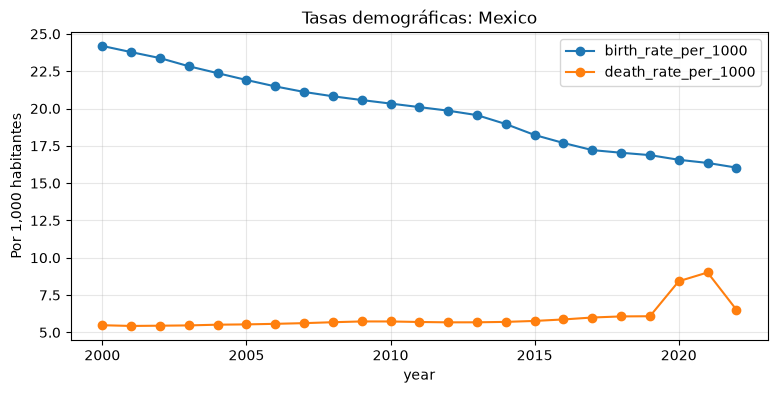

In [25]:
entidad = "Mexico" if "Mexico" in demografia["entity"].values else demografia["entity"].iloc[0]
ejemplo = demografia[demografia["entity"] == entidad].sort_values("year")

ejemplo.plot(x="year", y=["birth_rate_per_1000", "death_rate_per_1000"],
             marker="o", figsize=(9, 4), title=f"Tasas demográficas: {entidad}")
plt.ylabel("Por 1,000 habitantes")
plt.grid(alpha=0.3)
plt.show()

## 12. Guardar el resultado

El CSV se guarda en `data/processed`. Contiene solamente las entidades y años con datos compartidos por las seis fuentes.

In [46]:
from pathlib import Path

carpeta_salida = Path("../data/processed")
carpeta_salida.mkdir(parents=True, exist_ok=True)

salida = carpeta_salida / "demografia_owid_2000_2022.csv"
demografia.to_csv(salida, index=False)

print(f"Archivo guardado: {salida.resolve()} | filas: {len(demografia)}")

Archivo guardado: C:\Users\PMaganaC\OneDrive\Documentos\Universidad\semestre 5\bigdata\U3_1_modelados_ml\data\processed\demografia_owid_2000_2022.csv | filas: 4244
